<a href="https://colab.research.google.com/github/ishwaripatil618-lang/Google-Skills-APIs-Explorer-Cloud-Storage-GSP421-qwiklabs-arcade-/blob/main/AI_ML_Internship_Project_2_CNN_CIFAR10_ipynb0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")

TensorFlow version: 2.20.0
Keras version: 3.13.2
GPUs available: 1


In [ ]:
# Step 1: Load CIFAR-10

CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

(X_train_c, y_train_c), (X_test_c, y_test_c) = keras.datasets.cifar10.load_data()

print(f"Train: {X_train_c.shape}")
print(f"Test : {X_test_c.shape}")
print(f"Labels: {y_train_c.shape}")
print(f"Pixel range: {X_train_c.min()} to {X_train_c.max()}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1932s 11us/step
Train: (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)
Labels: (50000, 1)
Pixel range: 0 to 255


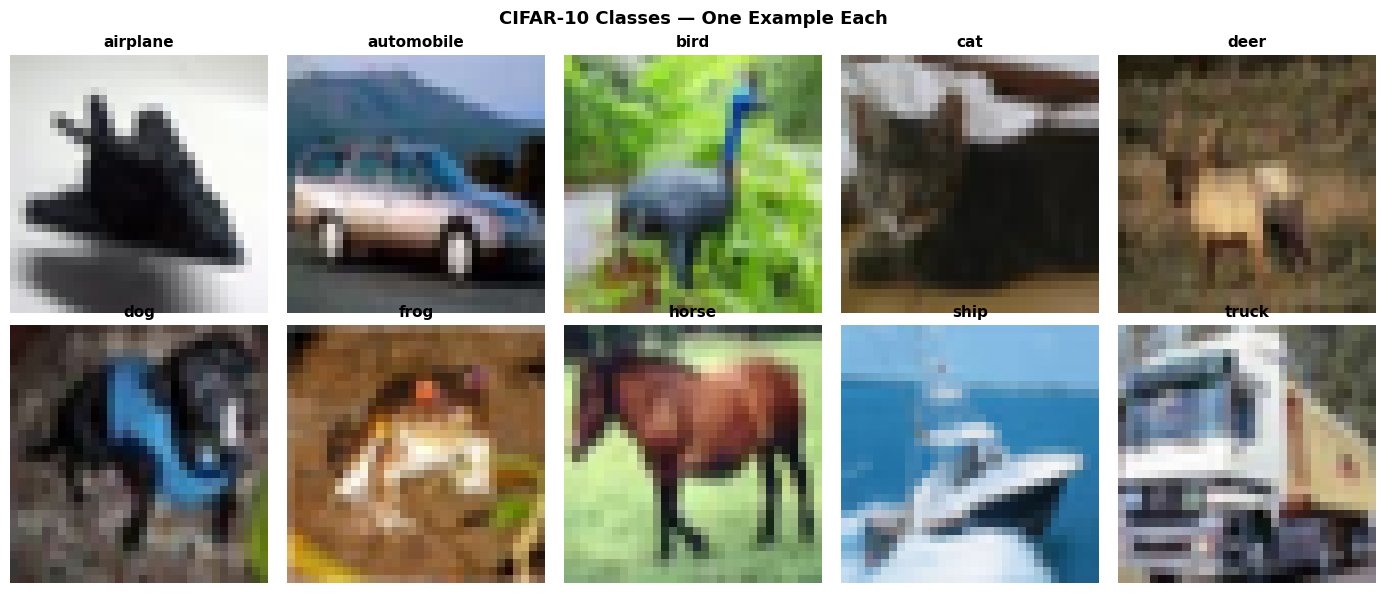

In [ ]:
# Show one image from each CIFAR-10 class

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, cls in enumerate(CLASS_NAMES):
    idx = np.where(y_train_c.flatten() == i)[0][0]
    ax = axes[i // 5, i % 5]
    ax.imshow(X_train_c[idx])
    ax.set_title(cls, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle(
    'CIFAR-10 Classes — One Example Each',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('cifar10_classes.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1]

X_train_c = X_train_c.astype('float32') / 255.0
X_test_c = X_test_c.astype('float32') / 255.0

# One-hot encode labels

y_train_c_ohe = to_categorical(y_train_c, num_classes=10)
y_test_c_ohe = to_categorical(y_test_c, num_classes=10)

print("Training images:", X_train_c.shape)
print("Test images:", X_test_c.shape)
print("Training labels:", y_train_c_ohe.shape)
print("Test labels:", y_test_c_ohe.shape)
print("Pixel range:", X_train_c.min(), "to", X_train_c.max())

Training images: (50000, 32, 32, 3)
Test images: (10000, 32, 32, 3)
Training labels: (50000, 10)
Test labels: (10000, 10)
Pixel range: 0.0 to 1.0


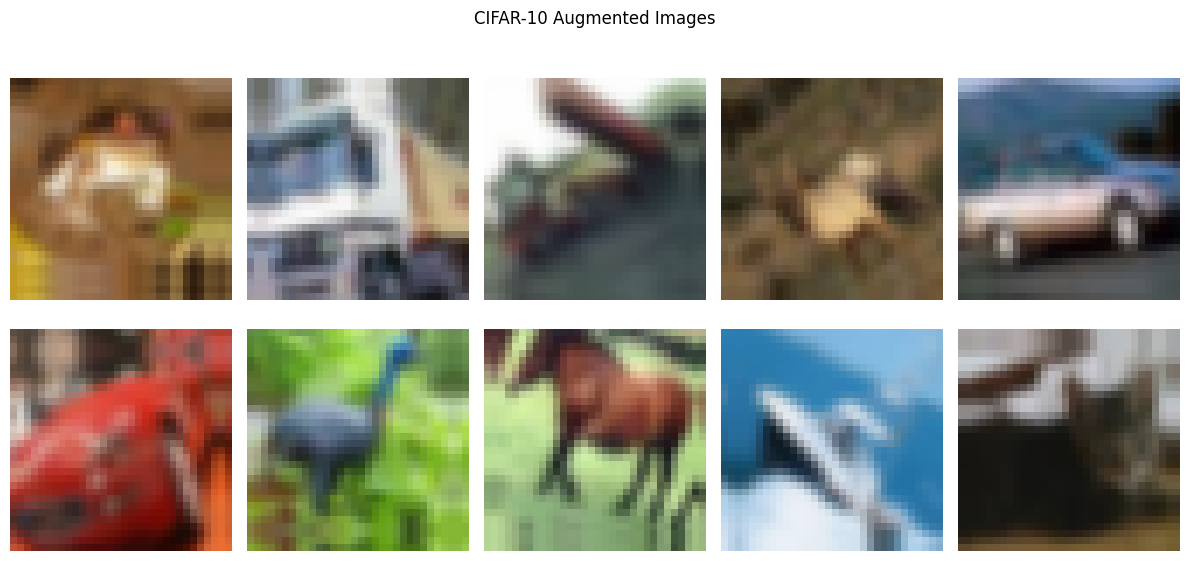

In [ ]:
# Step 2: Data Augmentation

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

# Show augmented examples
plt.figure(figsize=(12, 6))

for i in range(10):
    augmented_image = data_augmentation(
        X_train_c[i:i+1],
        training=True
    )

    plt.subplot(2, 5, i + 1)
    plt.imshow(augmented_image[0])
    plt.axis('off')

plt.suptitle("CIFAR-10 Augmented Images")
plt.tight_layout()
plt.show()

In [ ]:
def build_cifar10_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        # BLOCK 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv1'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D(pool_size=(2,2), name='pool1'),
        layers.Dropout(0.25),

        # BLOCK 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv3'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv4'),
        layers.MaxPooling2D(pool_size=(2,2), name='pool2'),
        layers.Dropout(0.25),

        # BLOCK 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv5'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv6'),
        layers.MaxPooling2D(pool_size=(2,2), name='pool3'),
        layers.Dropout(0.25),

        # CLASSIFIER
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='dense1'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])

    return model

model = build_cifar10_cnn()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the CIFAR-10 CNN

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Train the CIFAR-10 CNN

print("Training CNN on CIFAR-10...")

history = model.fit(
    data_augmentation(X_train_c, training=True),
    y_train_c_ohe,
    epochs=20,
    batch_size=128,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")
print(f"Epochs trained: {len(history.history['accuracy'])}")

Training CNN on CIFAR-10...
Epoch 1/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.3376 - loss: 1.9441 - val_accuracy: 0.1505 - val_loss: 3.1544 - learning_rate: 0.0010
Epoch 2/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4479 - loss: 1.5443 - val_accuracy: 0.5079 - val_loss: 1.3721 - learning_rate: 0.0010
Epoch 3/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5154 - loss: 1.3465 - val_accuracy: 0.4704 - val_loss: 1.4607 - learning_rate: 0.0010
Epoch 4/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5520 - loss: 1.2510 - val_accuracy: 0.4371 - val_loss: 1.7985 - learning_rate: 0.0010
Epoch 5/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5695 - loss: 1.2031 - val_accuracy: 0.5797 - val_loss: 1.1622 - learning_rate: 0.0010
Epoch 6/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6109 - loss: 1.0947 - val_accuracy: 0.5807 - val_loss: 1.1526 - learning_rate: 0.0010
Epoch 7/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step 

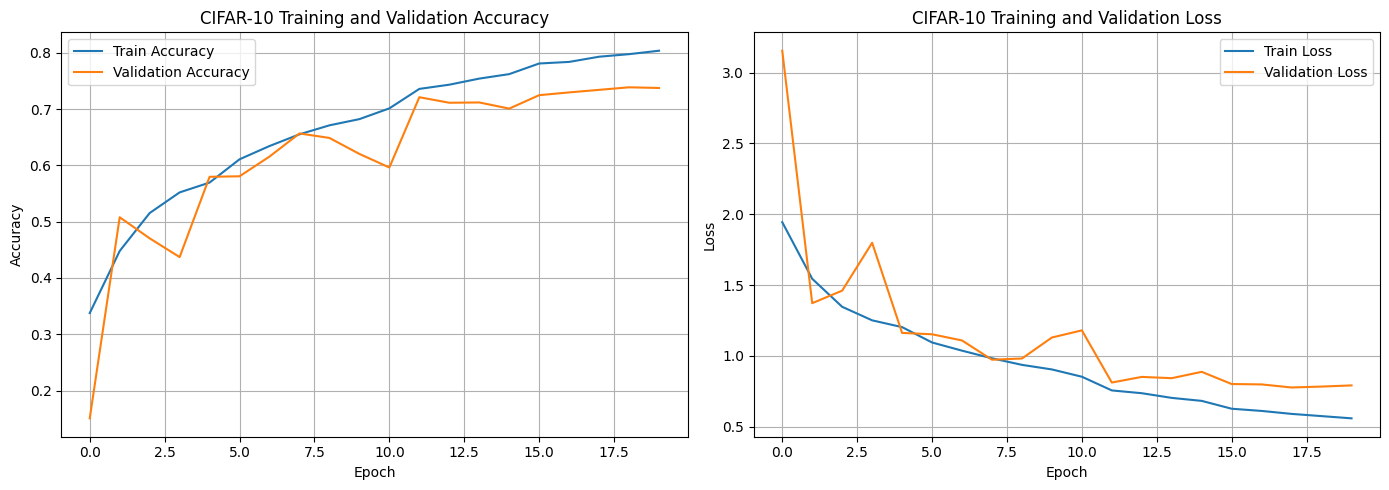

In [ ]:
# Step 5: Plot Training History

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('CIFAR-10 Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('CIFAR-10 Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('cifar10_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Step 6: Evaluate the CIFAR-10 CNN

test_loss, test_accuracy = model.evaluate(
    X_test_c,
    y_test_c_ohe,
    verbose=0
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 72.31%
Test Loss: 0.9103


In [ ]:
# Step 7: Predictions

y_pred_probs = model.predict(X_test_c)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_c.flatten()

print("Predictions generated successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predictions generated successfully!


Total misclassified: 2769 / 10000
Error rate: 27.69%


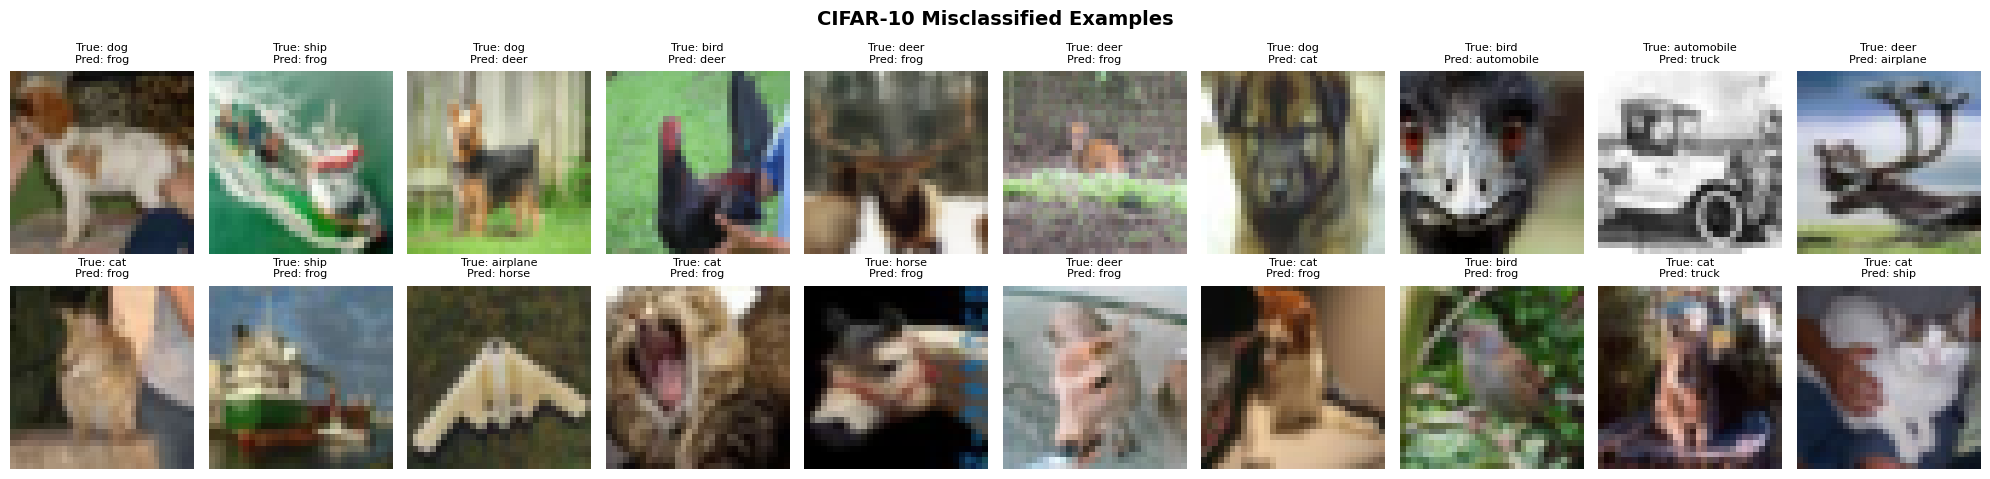

In [ ]:
# Step 8: Show Misclassified CIFAR-10 Images

wrong_idx = np.where(y_pred != y_true)[0]

print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)}")
print(f"Error rate: {len(wrong_idx) / len(y_true) * 100:.2f}%")

fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i, idx in enumerate(wrong_idx[:20]):
    ax = axes[i // 10, i % 10]

    ax.imshow(X_test_c[idx])

    ax.set_title(
        f"True: {CLASS_NAMES[y_true[idx]]}\n"
        f"Pred: {CLASS_NAMES[y_pred[idx]]}",
        fontsize=8
    )

    ax.axis('off')

plt.suptitle(
    'CIFAR-10 Misclassified Examples',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'cifar10_errors.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()